In [1]:
import platform                  # Python 3.9.16
import sys

import numpy             as np   # Numpy 1.23.2
import pandas            as pd   # Pandas 2.0.3
import matplotlib.pyplot as plt
%matplotlib inline
print(plt.rcParams.keys())
plt.rcParams.update({
    'font.size'     : 16,
    'axes.grid'     : True,
    'grid.linestyle': '--',
    'lines.linewidth': 2,
})


savedir = "./"

import sklearn          as sk    # Scikit-Learn 1.3.0
import statsmodels.api  as sm    # Statsmodels 0.14.0
import tensorflow       as tf    # Tensor Flow 2.12.0
import tensorflow.keras as keras # Keras 2.12.0
tf.random.set_seed(42)

print(f"Python Platform: {platform.platform()}")
print(f"Python {sys.version}")
print(f"Pandas {pd.__version__}")
print(f"Numpy {np.__version__}")
print()
print(f"Scikit-Learn {sk.__version__}")
print(f"Statsmodels {sm.__version__}")
print(f"Tensor Flow {tf.__version__}")
print(f"Keras {keras.__version__}")
print()

gpu_list = tf.config.list_physical_devices('GPU')
gpu_num = len(gpu_list)
print("GPU is", gpu_num, "available. <==", (gpu_list))

KeysView(RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'b

In [2]:
import statsmodels.datasets.co2 as co2

co2_raw = co2.load().data
df_raw = co2_raw.iloc[1501:] # 1987以降のデータ (15年分) を抽出
df = df_raw.resample('QS').mean() # 0.25年次データに変換 (Quarterの初日を取得)"
df["std"] = df_raw.resample('QS').std() # 0.25年次データの標準偏差 (Quarterの初日を取得)"
df["var"] = df_raw.resample('QS').var() # 0.25年次データの分散 (Quarterの初日を取得)"
df.index.name = "YEAR"

display(df_raw)
display(df)

,co2
1987-01-03,347.6
1987-01-10,348.3
1987-01-17,348.2
1987-01-24,347.9
1987-01-31,348.0
...,...
2001-12-01,370.3
2001-12-08,370.8
2001-12-15,371.2
2001-12-22,371.3


,co2,std,var
YEAR,,,
1987-01-01,348.607692,0.794210,0.630769
1987-04-01,351.284615,0.504721,0.254744
1987-07-01,347.984615,1.387952,1.926410
1987-10-01,347.661538,1.168716,1.365897
1988-01-01,351.353846,0.935962,0.876026
1988-04-01,353.815385,0.496397,0.246410
1988-07-01,350.561538,1.605998,2.579231
1988-10-01,350.114286,1.150824,1.324396
1989-01-01,353.125000,0.517204,0.267500


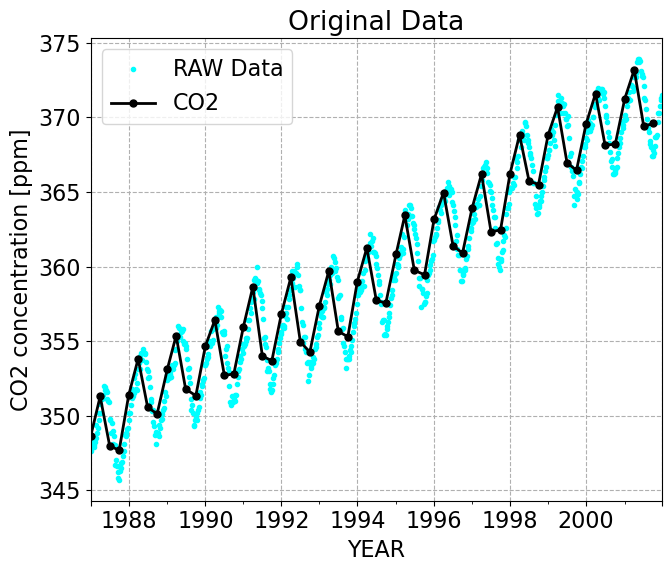

In [3]:
trend_w = 4

df["trend"] = df["co2"].rolling(window=trend_w, center=True).mean()

# それぞれの成分を描画
fig, ax = plt.subplots(1, 1, figsize=(7, 6), sharex=True)

df_raw["co2"].plot(ax=ax, c='cyan', marker='o', markersize=3, linewidth=0, label='RAW Data')


# (df["co2"] - df["trend"])  .plot(ax=ax[1], c='black', marker='o',    markersize=5)
# (df["trend"] - df["trend"]).plot(ax=ax[1], c='red',   linestyle='--', linewidth=1)
# ax[1].set_title("residual (Original - trend)")


df["co2"]    .plot(ax=ax, c='black', marker='o', markersize=5, label='CO2')
# df["trend"]  .plot(ax=ax, c='red',   linestyle='--', linewidth=1, label=f'trend \n(MA filtered, w={trend_w})')

ax.set_ylabel("CO2 concentration [ppm]")
ax.set_title("Original Data")
ax.legend(loc='upper left')

plt.tight_layout()

# plt.savefig(savedir + "1a_data_trend.png")
plt.show()

# 学習データ、教師データへの分割

In [4]:
# df["X"] = np.arange(0, len(df), 1) #ダミーの説明変数

min_val, max_val = np.min(df["co2"].values), np.max(df["co2"].values)
scale = max_val - min_val
df["y"] = (df["co2"].values - min_val) / scale #正規化
df["y_var"] = df["var"].values / scale**2      #正規化

display(df.head())
display(df.describe())

,co2,std,var,trend,y,y_var
YEAR,,,,,,
1987-01-01,348.607692,0.794210,0.630769,NaN,0.037048,0.000967
1987-04-01,351.284615,0.504721,0.254744,NaN,0.141867,0.000391
1987-07-01,347.984615,1.387952,1.926410,348.884615,0.012651,0.002954
1987-10-01,347.661538,1.168716,1.365897,349.571154,0.000000,0.002094
1988-01-01,351.353846,0.935962,0.876026,350.203846,0.144578,0.001343


,co2,std,var,trend,y,y_var
count,60.000000,60.000000,60.000000,57.000000,60.000000,60.000000
mean,359.827051,1.079970,1.378469,359.830263,0.476360,0.002114
std,6.891717,0.464467,1.062925,6.350128,0.269856,0.001630
min,347.661538,0.326599,0.106667,348.884615,0.000000,0.000164
25%,354.190385,0.643314,0.413942,355.019231,0.255648,0.000635
50%,359.357692,1.086947,1.183269,358.881731,0.457982,0.001814
75%,365.859615,1.429811,2.047051,364.963462,0.712575,0.003139
max,373.200000,2.003555,4.014231,370.865385,1.000000,0.006155


作ったデータを、学習用データと試験用データに分割します。

train_size: 40 1987-01-01 00:00:00 1996-10-01 00:00:00
test_size: 20 1997-01-01 00:00:00 2001-10-01 00:00:00


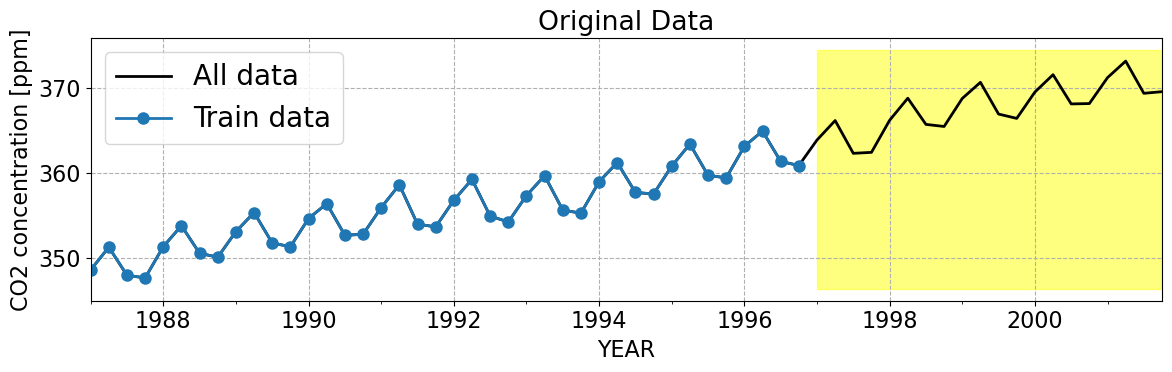

In [36]:
ratio = 0.67 #学習用データの割合（80%）
train_size = int(ratio * len(df)) #前半(学習用) と 後半(試験用)に分ける
test_size  = len(df) - train_size #試験用データのサイズ

train = df.iloc[:train_size] #全データから前半を抜粋
test  = df.iloc[train_size:] #後半を抜粋

print("train_size:", train_size, df.index[0], df.index[train_size-1])
print("test_size:", test_size, df.index[train_size], df.index[-1])

# 正規化されたCO2濃度の推移を図示して確認する
fig, ax = plt.subplots(figsize=(12, 4))
df["co2"]   .plot(label='All data',   linewidth=2,              color='black')
train["co2"].plot(label='Train data', marker='o', markersize=8, color='C0')
# test["co2"] .plot(label='Test data',  marker='o', markersize=8, color='')
ymin, ymax = ax.get_ylim()
ax.fill_between(test.index, ymin, ymax, color='yellow', alpha=0.5) # colorize forecast target period

ax.set_ylabel("CO2 concentration [ppm]")
ax.set_title("Original Data")
ax.grid(True)

plt.legend(fontsize=20)

plt.tight_layout()
# plt.savefig(savedir + "3a_train_test.png")
plt.show()

### 関数の定義
オレオレ関数で恐縮ですが、実行結果を表示するための関数を定義しておきます。

In [15]:
def my_get_rmse(pred: pd.Series, true: pd.Series) -> pd.Series:
    """真値と予測値のRMSEを計算する関数
    Args:
        pred: 予測値
        true: 真値
    Returns:
        rmses: RMSEのリスト
    """
    y_pred = pred.values.reshape(-1, 1)
    y_true = true.values.reshape(-1, 1)
    y_error = y_true - y_pred
    rmses = np.sqrt(np.mean(y_error**2, axis=1))

    return pd.Series(rmses, index=pred.index)

In [16]:
def my_plot_results(pred_test: pd.Series) -> plt.figure:
    """真値と予測値の比較をプロットする関数
    Args:
        pred_test: 試験用データの予測
    Returns:
        fig: Figure object.
        ax: Axes object (左列, 元データ).
        bx: Axes object (右列, RMSE).
    """

    # STL分解
    stl_true = sm.tsa.STL(test["co2"]).fit()
    stl_test = sm.tsa.STL(pred_test)  .fit()

    # それぞれの成分を描画
    fig, axes = plt.subplots(4, 2, figsize=(15, 12), sharex=True)
    ax,  bx   = axes.transpose()[0], axes.transpose()[1]

    for i in range(4):
        ax[i].set_ylabel(["Original Data", "Trend", "Seasonal\n", "Residual"][i])

    # 元データ
    ax[0].set_title("ax[0].set_title(name)")
    test["co2"]      .plot(ax=ax[0], c='black', label='Original Data')
    pred_test        .plot(ax=ax[0], c='C1'   , label='Prediction')

    stl_true.trend   .plot(ax=ax[1], c='black')
    stl_test.trend   .plot(ax=ax[1], c='C1')

    stl_true.seasonal.plot(ax=ax[2], c='black')
    stl_test.seasonal.plot(ax=ax[2], c='C1')

    stl_true.resid   .plot(ax=ax[3], c='black')
    stl_test.resid   .plot(ax=ax[3], c='C1')

    # RMSE
    rmse_original = my_get_rmse(pred_test,         test["co2"])
    rmse_trend    = my_get_rmse(stl_test.trend,    stl_true.trend)
    rmse_seasonal = my_get_rmse(stl_test.seasonal, stl_true.seasonal)
    rmse_resid    = my_get_rmse(stl_test.resid,    stl_true.resid)

    bx[0].set_title("bx[0].set_title(name)")
    rmse_original.plot(ax=bx[0], c='C1')
    rmse_trend   .plot(ax=bx[1], c='C1')
    rmse_seasonal.plot(ax=bx[2], c='C1')
    rmse_resid   .plot(ax=bx[3], c='C1')

    ax[0].legend()
    plt.tight_layout()

    return fig, ax, bx

In [17]:
def my_plot_results(pred_train: pd.Series, pred_test: pd.Series, n_lag: int=0) -> plt.figure:
    """真値と予測値の比較をプロットする関数
    Args:
        pred_test: 試験用データの予測
    Returns:
        fig: Figure object.
        ax: Axes object (左列, 元データ).
        bx: Axes object (右列, RMSE).
    """

    fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
    ax,  bx   = [axes[0]], [axes[1]]
    

    # 元データ
    pred_train_trend = pred_train.rolling(window=trend_w, center=True).mean()
    pred_trend = pred_test.rolling(window=trend_w, center=True).mean()
    ax[0].set_title("ax[0].set_title(name)")
    ax[0].set_ylabel("Original Data [ppm]")

    df["trend"].plot(ax=ax[0], c='gray',  linewidth=1, label='Trend', linestyle='--')
    pred_trend .plot(ax=ax[0], c='red',   linewidth=1, label='Prediction (trend)', linestyle='--')

    df["co2"]   .plot(ax=ax[0], c='black', linewidth=2, label='Original Data')
    train["co2"].plot(ax=ax[0], c='C0',    linewidth=3, label='Train Data')

    pred_train      .plot(ax=ax[0], c='red', linewidth=2, label='Prediction (train)')
    pred_train_trend.plot(ax=ax[0], c='red', linewidth=1, label='Prediction (train, trend)', linestyle='--')
    pred_test       .plot(ax=ax[0], c='red', linewidth=5, label='Prediction')


    # RMSE
    rmse_train = my_get_rmse(pred_train, train["co2"].iloc[n_lag:])
    rmse_test  = my_get_rmse(pred_test,  test["co2"])
    bx[0].set_ylabel("Root Mean Square Error [ppm]\n")

    rmse_train.plot(ax=bx[0], c='red', linewidth=2)
    rmse_test .plot(ax=bx[0], c='red', linewidth=5)

    bx[0].set_xlim(df.index[0], df.index[-1])


    handle, label = ax[0].get_legend_handles_labels()
    pickup = [2, 3, 6]
    
    handle = [handle[i] for i in pickup]
    label  = [label [i] for i in pickup]

    bx[0].legend(handle, label, loc='upper left', fontsize=20)
    plt.tight_layout()

    return fig, ax, bx

In [18]:
def my_tsa_plot_results(trained_model, n_lag: int=0) -> plt.figure:
    """真値と予測値の比較をプロットする関数
    Args:
        trained_model: 学習済みモデル
        n_lag: 予測値のずらし量
    Returns:
        fig: Figure object.
        ax: Axes object (左列, 元データ).
        bx: Axes object (右列, RMSE).
    """

    prediction_result = trained_model.get_prediction(n_lag, train_size-1)
    predinction_val = prediction_result.predicted_mean

    forecast_result = trained_model.get_forecast(test_size)
    forecast_val = forecast_result.predicted_mean

    pred_train = pd.Series(predinction_val * scale + min_val,
                           index=train.index[n_lag:])

    pred_test = pd.Series(forecast_val * scale + min_val, 
                          index=test.index)

    fig, ax, bx = my_plot_results(pred_train, pred_test, n_lag=n_lag)


    # 予測区間を描画
    train_se = prediction_result.se_mean * scale
    test_se  = forecast_result  .se_mean * scale

    # df["std"].plot(ax=bx[0], color="olive", linewidth=1, label="sample std")

    bx[0].fill_between(train.index[n_lag:], train_se, 0, color='orange', alpha=0.2)
    bx[0].fill_between(test.index,          test_se,  0, color='orange', alpha=0.2)

    bx[0].set_xlim(df.index[0], df.index[-1])

    return fig, ax, bx

 This problem is unconstrained.

   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -2.09812D+00    |proj g|=  1.54869D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    6      2     22      1     0     0   1.352D-02  -2.098D+00
  F =  -2.0981162154645245     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


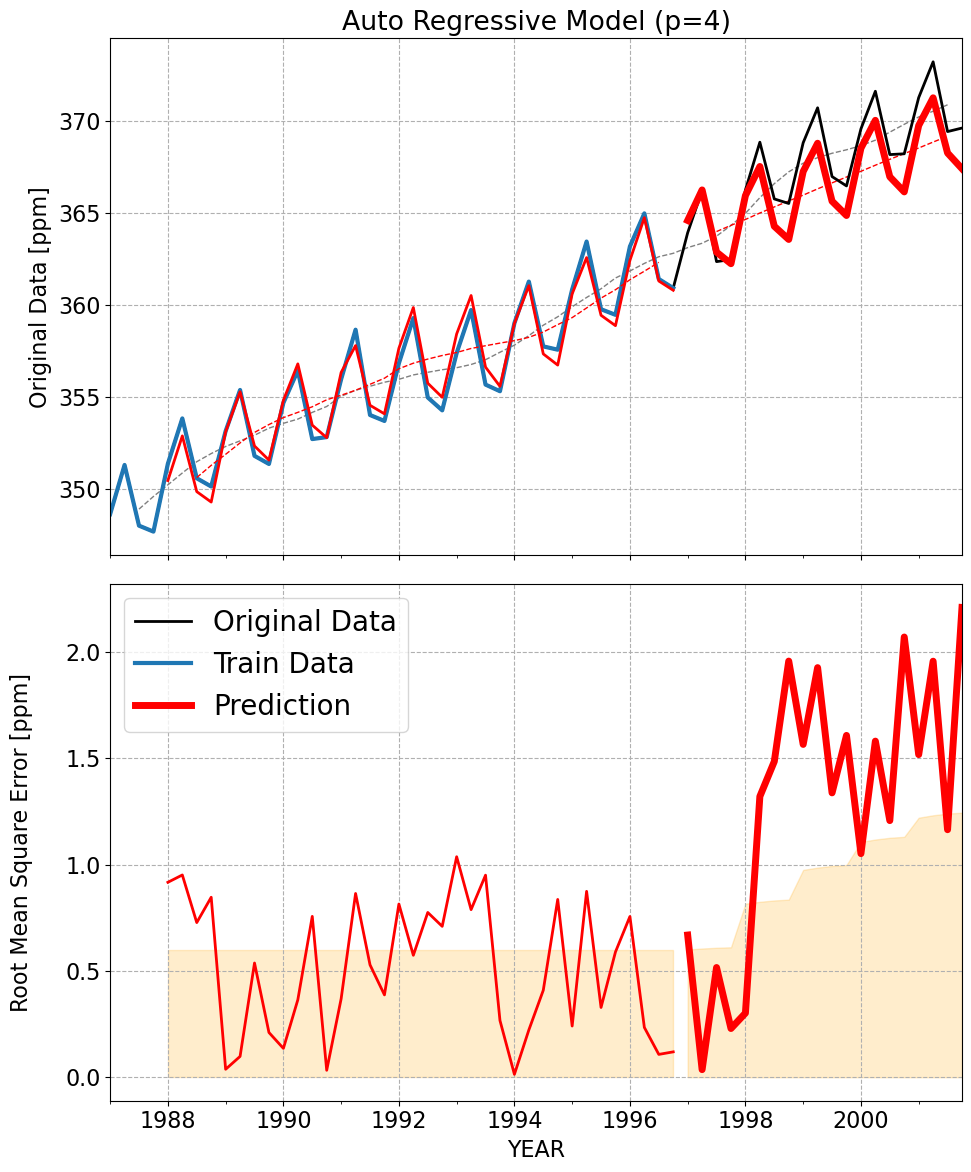

In [19]:
p = 4

ar = sm.tsa.SARIMAX(train["y"].values,
                    order=(p, 0, 0), 
                    trend='c', 
                    enforce_stationarity=False, 
                    enforce_invertibility=False
                    ).fit(maxiter=1000)

fig, ax, bx = my_tsa_plot_results(ar, n_lag=p)

ax[0].set_title(f"Auto Regressive Model (p={p})")

# plt.savefig(savedir + "4a_ar.png")
plt.show()

In [20]:
display(ar.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   40
Model:               SARIMAX(4, 0, 0)   Log Likelihood                  83.925
Date:                Thu, 16 May 2024   AIC                           -155.849
Time:                        14:16:31   BIC                           -146.348
Sample:                             0   HQIC                          -152.533
                                 - 40                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0617      0.012      5.304      0.000       0.039       0.085
ar.L1          0.1270      0.095      1.332      0.183      -0.060       0.314
ar.L2         -0.1253      0.091     -1.385      0.166      -0.303       0.052
ar.L3          0.1174      0.086      1.358      0.174      -0.052       0.287
ar.L4          0.8611      0.083     10.391      0.000       0.699       1.024
sigma2         0.0006      0.000      2.403      0.016       0.000       0.001
===================================================================================
Ljung-Box (L1) (Q):                  16.12   Jarque-Bera (JB):                 2.10
Prob(Q):                              0.00   Prob(JB):                         0.35
Heteroskedasticity (H):               0.70   Skew:                             0.05
Prob(H) (two-sided):                  0.55   Kurtosis:                         1.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# オリジナルの AR-realizer


In [21]:
def myAR(const, coefs: np.ndarray, y0: np.ndarray, t_size: int) -> np.ndarray:
    """ARモデルの予測を行う関数
    Args:
        coefs: ARモデルの係数
        y0: 初期値
        t_size: 予測するデータ数
    Returns:
        y_pred: 予測値
    """

    p = len(coefs)
    t_max = t_size + p
    y_pred = np.zeros(t_max)

    y_pred[:p] = y0
    for t in range(p, t_max):
        y_pred[t] = const + np.dot(coefs[::-1], y_pred[t-p:t])

    return y_pred[p:]


In [37]:
def plot_my_AR(const: float, coefs: np.ndarray, y0: np.ndarray, t_size: int) -> plt.figure:
    """ARモデルの予測を行う関数
    Args:
        coefs: ARモデルの係数
        y0: 初期値
        t_size: 予測するデータ数
        ax: Axes object
    Returns:
        ax: Axes object
    """

    y_pred = myAR(const, coefs, y0, t_size)

    fig, ax = plt.subplots(figsize=(12, 4))

    pred_test = pd.Series(y_pred * scale + min_val, 
                      index=test.index)
    
    df["co2"]   .plot(ax=ax, c='black', linewidth=2, label='Original Data')
    train["co2"].plot(ax=ax, c='C0',    linewidth=3, label='Train Data')
    pred_test.plot(ax=ax, c='red', linewidth=5, label='Prediction')

    ymin, ymax = ax.get_ylim()
    ax.fill_between(test.index, ymin, ymax, color='yellow', alpha=0.5) # colorize forecast target period

    ax.grid(True)

    return fig, ax

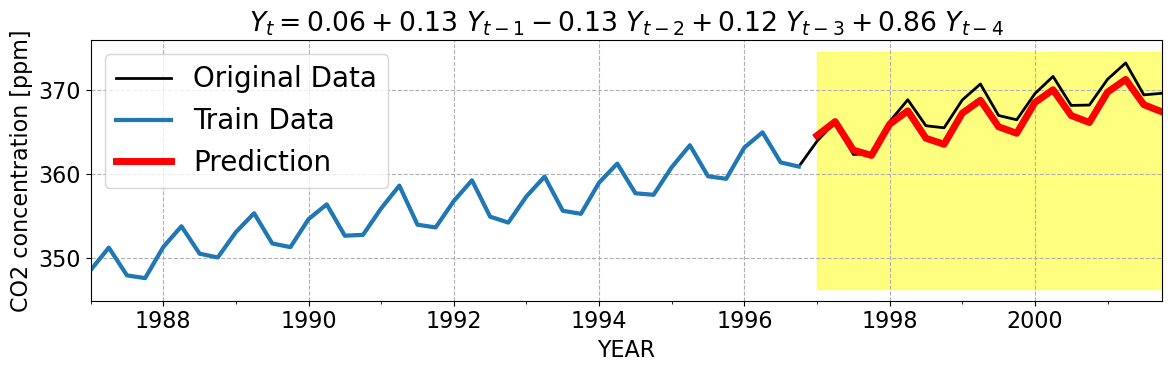

In [38]:
y0 = train["y"].values[-p:]
coefs = np.array([0.1270, -0.1253, 0.1174, 0.8611])
const = 0.0617

fig, ax = plot_my_AR(const, coefs, y0, test_size)

plt.legend(fontsize=20)

ax.set_title(r"$ Y_t = 0.06 + 0.13 \ Y_{t-1} - 0.13 \ Y_{t-2} + 0.12 \ Y_{t-3} + 0.86 \ Y_{t-4} $")
ax.set_ylabel("CO2 concentration [ppm]")

plt.tight_layout()
# plt.savefig(savedir + "ar_good.png")
plt.show()

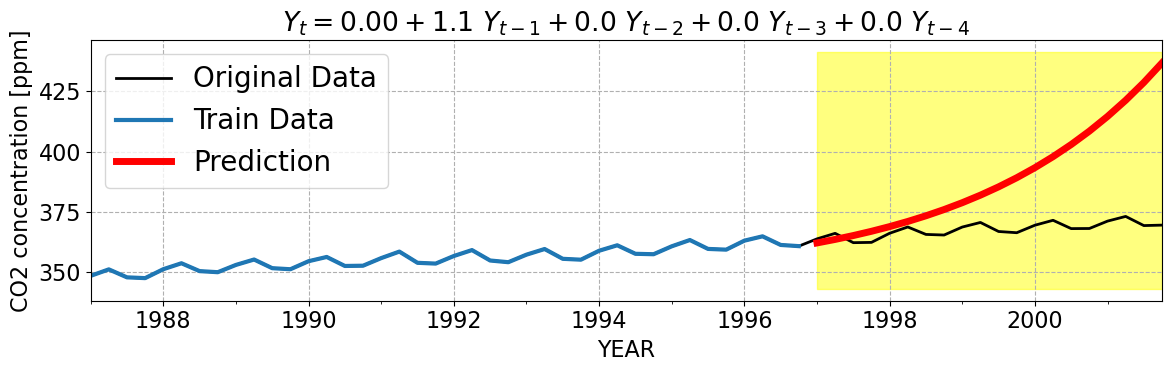

In [39]:
y0 = train["y"].values[-p:]
coefs = np.array([1.1, 0.0, 0.0, 0.0])
const = 0.0

fig, ax = plot_my_AR(const, coefs, y0, test_size)

plt.legend(fontsize=20)

ax.set_title(r"$ Y_t = 0.00 + 1.1 \ Y_{t-1} + 0.0 \ Y_{t-2} + 0.0 \ Y_{t-3} + 0.0 \ Y_{t-4} $")
ax.set_ylabel("CO2 concentration [ppm]")

plt.tight_layout()
# plt.savefig(savedir + "ar_bad_exp.png")
plt.show()

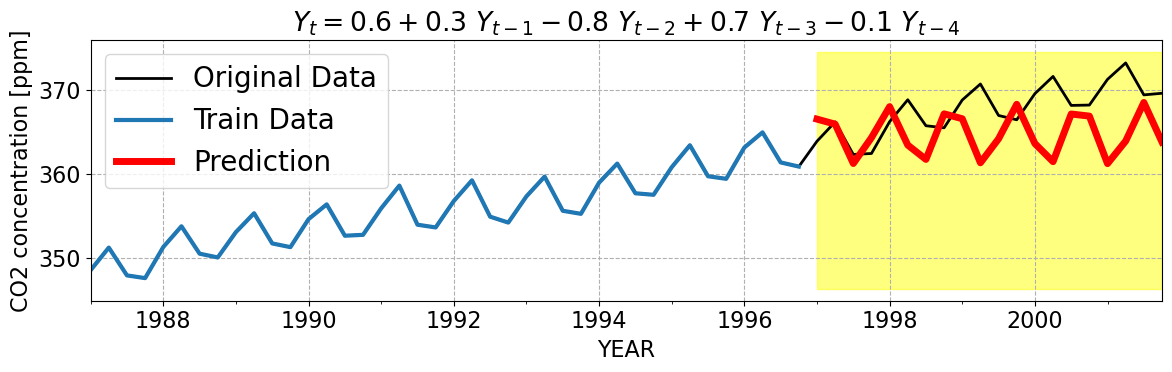

In [40]:
y0 = train["y"].values[-p:]
coefs = np.array([0.3, -0.8, 0.7, -0.1])
const = 0.6

fig, ax = plot_my_AR(const, coefs, y0, test_size)

plt.legend(fontsize=20)

ax.set_title(r"$ Y_t = 0.6 + 0.3 \ Y_{t-1} - 0.8 \ Y_{t-2} + 0.7 \ Y_{t-3} - 0.1 \ Y_{t-4} $")
ax.set_ylabel("CO2 concentration [ppm]")

plt.tight_layout()
# plt.savefig(savedir + "ar_bad_osc.png")
plt.show()